In [2]:
from fedvaeexample.task import Net, get_processed_data

In [3]:
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
from datasets import Dataset
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix

## Dataset Preparation

In [4]:
# Custom batch collation function
def custom_collate(batch_list):
    """
    Custom collate function to handle datasets with both features and target column.
    
    Args:
        batch_list: List of items from the dataset
        
    Returns:
        Tuple of (features, labels) tensors
    """
    samples = []
    labels = []
    
    for item in batch_list:
        # Filter out the 'target' key and convert remaining items to features
        features = []
        
        for key, value in item.items():
            if key == 'target':
                labels.append(value)
            elif key.isdigit() or (isinstance(key, int)):
                # Handle numeric feature columns
                features.append(value)
        
        # If no target was found, use a default label
        if len(labels) < len(samples) + 1:
            labels.append(0)
            
        sample = torch.tensor(features, dtype=torch.float32)
        samples.append(sample)
    
    # Stack samples and labels into tensors
    features_tensor = torch.stack(samples)
    labels_tensor = torch.tensor(labels)
    
    return features_tensor, labels_tensor
    
def get_data(dataset_path, target_label=0):
    data = get_processed_data(dataset_path)
    
    data_shape = data.shape[1]
    print(f'data feature dim.: {data_shape}')
    
    # Create DataFrame with default index and column handling
    df = pd.DataFrame(data)
    
    # Add the same target label for all rows
    df['target'] = target_label
    
    # Convert to HuggingFace dataset
    dataset = Dataset.from_pandas(df)
    
    return dataset, data_shape

def combine_and_shuffle_datasets(dataset_paths, target_labels, feature_dim=None):
    """
    Combine multiple datasets with different feature dimensions and assign appropriate target labels.
    
    Args:
        dataset_paths (list): List of paths to datasets
        target_labels (list): List of target labels corresponding to each dataset
        feature_dim (int, optional): Target feature dimension for all datasets. If None, uses the max dimension.
    
    Returns:
        Combined and shuffled dataset with uniform feature dimension
    """
    if len(dataset_paths) != len(target_labels):
        raise ValueError("Number of dataset paths must match number of target labels")
    
    datasets = []
    dims = []
    
    # First pass: get each dataset and determine dimensions
    for path, label in zip(dataset_paths, target_labels):
        data = get_processed_data(path)
        dims.append(data.shape[1])
        
        # Create DataFrame
        df = pd.DataFrame(data)
        
        # Add the target label for all rows
        df['target'] = label
        
        datasets.append(df)
    
    # Determine target dimension
    if feature_dim is None:
        feature_dim = max(dims)
    
    # Second pass: pad or truncate features to match target dimension
    standardized_dfs = []
    for i, df in enumerate(datasets):
        current_dim = dims[i]
        
        if current_dim < feature_dim:
            # Pad with zeros to match target dimension
            for j in range(current_dim, feature_dim):
                df[j] = 0
        elif current_dim > feature_dim:
            # Truncate to match target dimension
            df = df.iloc[:, :feature_dim].copy()
            # Make sure to keep the target column
            df['target'] = datasets[i]['target']
        
        standardized_dfs.append(df)
    
    # Combine all datasets
    combined_df = pd.concat(standardized_dfs, ignore_index=True)
    
    # Shuffle the combined dataset
    combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)
    
    # Separate features and target
    features = combined_df.drop('target', axis=1)
    targets = combined_df['target']
    
    # Convert to HuggingFace dataset
    combined_dataset = Dataset.from_pandas(combined_df)
    
    return combined_dataset, feature_dim

## Testing the model

In [5]:
def test(net, testloader, device):
    """Validate the VAE network on the entire test set and return a DataFrame with errors and true labels."""
    total, loss = 0, 0.0
    recon_total, kld_total = 0.0, 0.0
    
    # Lists to store all features, reconstructions, errors and labels
    all_features = []
    all_reconstructions = []
    all_recon_errors = []
    all_labels = []  # To store the true labels from the dataset
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(testloader):
            # Check if the batch contains labels (dataset with target attribute)
            if isinstance(batch, (list, tuple)) and len(batch) == 2:
                # If batch is (features, labels)
                features, labels = batch
                features = features.to(device)
                all_labels.extend(labels.cpu().numpy())
            else:
                # If batch is just features
                features = batch.to(device)
                # Use a default label if no labels are provided
                all_labels.extend([0] * len(features))
            
            # Forward pass through the VAE
            recon_features, mu, logvar = net(features)
            
            # Compute losses
            recon_loss = F.mse_loss(recon_features, features)
            kld_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
            batch_loss = recon_loss + 0.05 * kld_loss
            
            # Track statistics
            loss += batch_loss.item() * len(features)
            recon_total += recon_loss.item() * len(features)
            kld_total += kld_loss.item() * len(features)
            total += len(features)
            
            # Calculate per-sample reconstruction error
            sample_recon_errors = torch.mean(torch.square(recon_features - features), dim=1)
            
            # Store all samples
            for i in range(len(features)):
                all_features.append(features[i].cpu())
                all_reconstructions.append(recon_features[i].cpu())
                all_recon_errors.append(sample_recon_errors[i].item())
    
    # Convert lists to numpy arrays
    all_recon_errors = np.array(all_recon_errors)
    
    # Get the indices of the 10 worst reconstructed samples
    worst10 = np.argsort(all_recon_errors)[-10:][::-1]
    
    # Calculate average reconstruction error
    avg_recon_error = np.mean(all_recon_errors)
    print(f"Average reconstruction error: {avg_recon_error:.4f}")
    
    avg_loss = loss / total
    avg_recon = recon_total / total
    avg_kld = kld_total / total
    
    print(f"Test Loss: {avg_loss:.4f}, Recon: {avg_recon:.4f}, KLD: {avg_kld:.4f}")
    
    # Visualization code
    plt.figure(figsize=(20, 4))
    for i, idx in enumerate(worst10):
        # Get the feature size
        feature_size = all_features[idx].shape[0]
        
        # For features with size 35, we can use 7x5 dimensions
        if feature_size == 35:
            height, width = 7, 5
        else:
            # Try to find reasonable dimensions - prefer width > height
            factors = []
            for j in range(1, int(np.sqrt(feature_size)) + 1):
                if feature_size % j == 0:
                    factors.append((j, feature_size // j))
            
            # Choose dimensions closest to a reasonable aspect ratio
            if factors:
                factors.sort(key=lambda x: abs(x[1]/x[0] - 1.5))
                height, width = factors[0]
            else:
                height, width = 1, feature_size
        
        # Plot original image
        plt.subplot(2, 10, i + 1)
        plt.imshow(all_features[idx].reshape(height, width).numpy(), cmap='gray')
        plt.title("Original")
        plt.axis('off')
        
        # Plot reconstructed image
        plt.subplot(2, 10, i + 11)
        plt.imshow(all_reconstructions[idx].reshape(height, width).numpy(), cmap='gray')
        plt.title(f"RE {all_recon_errors[idx]:.3f}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Create a DataFrame similar to your example
    recons_df = pd.DataFrame({
        'error': all_recon_errors,
        'y_true': all_labels
    }).reset_index(drop=True)
    
    return avg_loss, recons_df

## Main function

Using device: cuda
Loading and combining datasets...
dataset shape=(14962, 28)
Normalized row of data:
(14962, 35)


/usr/local/lib/python3.10/dist-packages/pandas/core/dtypes/cast.py:1641: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])


dataset shape=(7122, 28)
Normalized row of data:
(7122, 42)


/usr/local/lib/python3.10/dist-packages/pandas/core/dtypes/cast.py:1641: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])
/usr/local/lib/python3.10/dist-packages/datasets/table.py:719: UserWarning: The DataFrame has column names of mixed type. They will be converted to strings and not roundtrip correctly.
  return cls(pa.Table.from_pandas(*args, **kwargs))
/tmp/ipykernel_9321/1752629708.py:62: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for 

Dataset loaded. Data shape (input dimension): 35
DataLoader created.
Instantiating model Net(input_dim=35, latent_dim=10, hidden_dim=64)
Loading pre-trained weights from: outputs/2025-04-22/07-50-20/model_state_loss_0.041428_round_3.pth
Model weights loaded successfully.
Model set to evaluation mode.
Starting testing...
Average reconstruction error: 0.0626
Test Loss: 0.0628, Recon: 0.0626, KLD: 0.0036


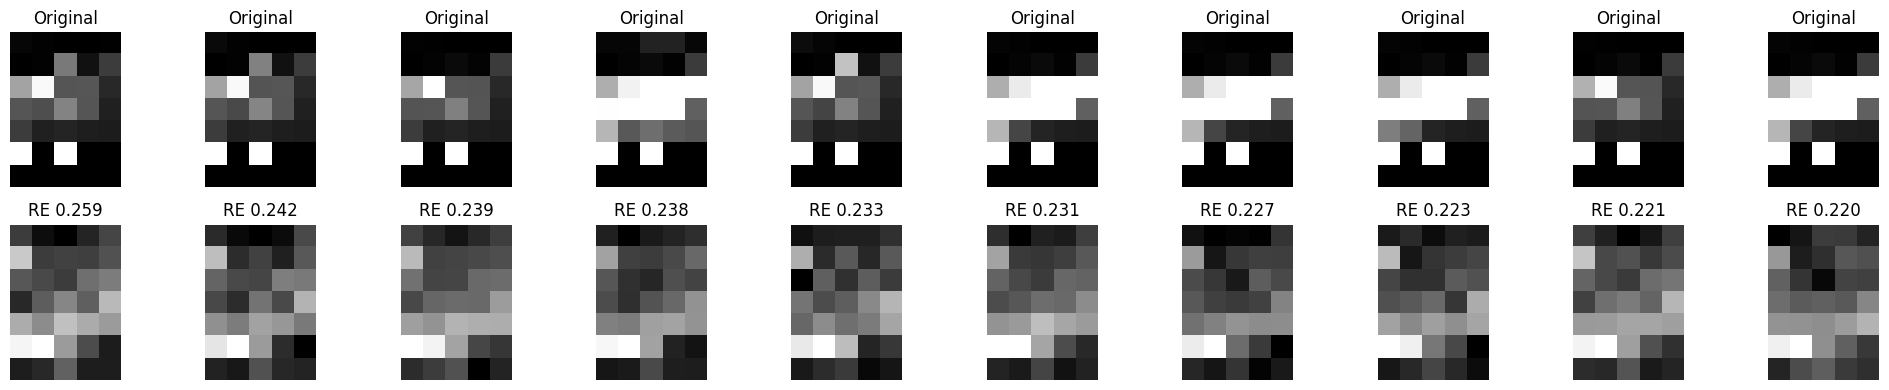

Testing complete. Average Reconstruction Loss: 0.06275333704356373


In [7]:
# Dataset paths and labels
dataset_paths = ["/workspace/datasets/desktop.tls/*.json", "/workspace/datasets/cic-aa.adware.tls/*.json"]
target_labels = [0, 1]  # Dataset1 has target 0, Dataset2 has target 1
feature_dim_used = 35 # The feature dimension used when creating the dataset

# Model Architecture Hyperparameters (MUST match the saved model)
# It's crucial that these dimensions are the same as the model you are loading
latent_dim = 10
hidden_dim = 64

# Path to the saved pre-trained model weights
# *** REPLACE THIS WITH THE ACTUAL PATH TO YOUR SAVED MODEL FILE ***

pretrained_model_path = os.path.join("outputs", "2025-04-22","07-50-20", "model_state_loss_0.041428_round_3.pth")

# Device configuration
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# --- Data Loading ---
print("Loading and combining datasets...")
# Ensure the feature_dim matches how the data should be processed for the pre-trained model
combined_dataset, data_shape = combine_and_shuffle_datasets(
    dataset_paths,
    target_labels,
    feature_dim=feature_dim_used
)
# The input_dim for the network must match the shape of the data from the dataset
input_dim = data_shape
print(f"Dataset loaded. Data shape (input dimension): {input_dim}")

# Create DataLoader
# Consider using a larger batch_size for potentially faster evaluation if memory allows
testloader = DataLoader(
    combined_dataset,
    batch_size=64, # Example: Increased batch size
    shuffle=False, # No need to shuffle for testing typically
    collate_fn=custom_collate # Assuming this handles batching correctly
)
print("DataLoader created.")

# --- Load Pre-trained Model ---

# 1. Instantiate the model architecture
#    The architecture (Net class) and its dimensions (input_dim, latent_dim, hidden_dim)
#    MUST exactly match the architecture of the model whose weights you are loading.
print(f"Instantiating model Net(input_dim={input_dim}, latent_dim={latent_dim}, hidden_dim={hidden_dim})")
autoencoder = Net(input_dim, latent_dim, hidden_dim)

# 2. Load the saved state dictionary
print(f"Loading pre-trained weights from: {pretrained_model_path}")
try:
    # Use map_location to ensure the model loads correctly regardless of
    # whether it was saved on CPU or GPU and where it's being loaded now.
    autoencoder.load_state_dict(torch.load(pretrained_model_path, map_location=device))
    print("Model weights loaded successfully.")
except FileNotFoundError:
    print(f"ERROR: Pre-trained model file not found at '{pretrained_model_path}'")
    print("Please check the path and ensure the file exists.")
    # Decide how to handle the error, e.g., exit() or raise Exception(...)
    exit() # Exit if the model file isn't found
except Exception as e:
    print(f"ERROR: Failed to load model weights: {e}")
    print("Ensure the model architecture in the code matches the saved model's architecture.")
    # Decide how to handle the error
    exit() # Exit on other loading errors


# 3. Move the model to the specified device (CPU or GPU)
autoencoder.to(device)

# 4. Set the model to evaluation mode
#    This is crucial! It disables layers like Dropout and BatchNorm updates,
#    which is necessary for inference/testing.
autoencoder.eval()
print("Model set to evaluation mode.")

# --- Testing ---
print("Starting testing...")
# Now use the loaded autoencoder for testing
avg_loss, recons_df = test(autoencoder, testloader, device) # Assuming test function is defined

print(f"Testing complete. Average Reconstruction Loss: {avg_loss}")
# print("Sample Reconstruction Data:")
# print(recons_df.head()) # Optional: display some reconstruction results

In [8]:
recons_df.head()  # To view the first few rows of the DataFrame

,error,y_true
0,0.094248,1
1,0.109797,0
2,0.038996,0
3,0.061053,0
4,0.038460,0


## Find the threshold for binary classification
* The metric we will choose for this problem is `Recall` , as we want to reduce `False Negatives` . Any Fraud transcation classified as Genuine may lead to unnoticed problems in the system, since there will never be anomaly detected. To find the right threshold value, several values will be tested to find the best combination of metrics. While our goal is to improve Recall, we will also keep track of the accuracy. The tested values will be percentiles of the reconstruction error values.
> reference: [Anomaly Detection with Autoencoders](https://github.com/AarnoStormborn/anomaly-detection-with-autoencoder/tree/main)

In [13]:
def thresholdTuning(df, iterations):
    
    thresh_df = {
        'threshold': [],
        'accuracy': [],
        'precision': [],
        'recall': []
    }
    
    for i in range(iterations):
        thresh_value = df['error'].quantile(i/iterations)
        preds = df['error'] > thresh_value
        cr = classification_report(df['y_true'], preds, output_dict=True)
        acc = cr['accuracy']
        prec = cr['macro avg']['precision']
        rc = cr['macro avg']['recall']
        
        thresh_df['threshold'].append(thresh_value)
        thresh_df['accuracy'].append(acc)
        thresh_df['precision'].append(prec)
        thresh_df['recall'].append(rc)
        
        print(f"Threshold: {thresh_value:.4f}\tAccuracy: {acc:.3f}\t\tPrecision: {prec:.3f}\tRecall Score: {rc:.3f}")
        
    return pd.DataFrame(thresh_df)
        
thresh_df = thresholdTuning(recons_df, 100)

Threshold: 0.0113	Accuracy: 0.323		Precision: 0.661	Recall Score: 0.500
Threshold: 0.0160	Accuracy: 0.333		Precision: 0.663	Recall Score: 0.507
Threshold: 0.0174	Accuracy: 0.343		Precision: 0.665	Recall Score: 0.515
Threshold: 0.0183	Accuracy: 0.353		Precision: 0.666	Recall Score: 0.522
Threshold: 0.0191	Accuracy: 0.363		Precision: 0.668	Recall Score: 0.530
Threshold: 0.0198	Accuracy: 0.373		Precision: 0.670	Recall Score: 0.537
Threshold: 0.0205	Accuracy: 0.382		Precision: 0.672	Recall Score: 0.544
Threshold: 0.0210	Accuracy: 0.393		Precision: 0.673	Recall Score: 0.552
Threshold: 0.0216	Accuracy: 0.403		Precision: 0.675	Recall Score: 0.559
Threshold: 0.0221	Accuracy: 0.413		Precision: 0.677	Recall Score: 0.566
Threshold: 0.0227	Accuracy: 0.423		Precision: 0.679	Recall Score: 0.574
Threshold: 0.0232	Accuracy: 0.433		Precision: 0.681	Recall Score: 0.581
Threshold: 0.0238	Accuracy: 0.442		Precision: 0.683	Recall Score: 0.589
Threshold: 0.0243	Accuracy: 0.452		Precision: 0.685	Recall Score

In [14]:
threshold = thresh_df[thresh_df['recall'] == thresh_df['recall'].max()]['threshold'].values[0]
print(f"Threshold with Maximum Recall: {threshold:.6f}")

Threshold with Maximum Recall: 0.075228


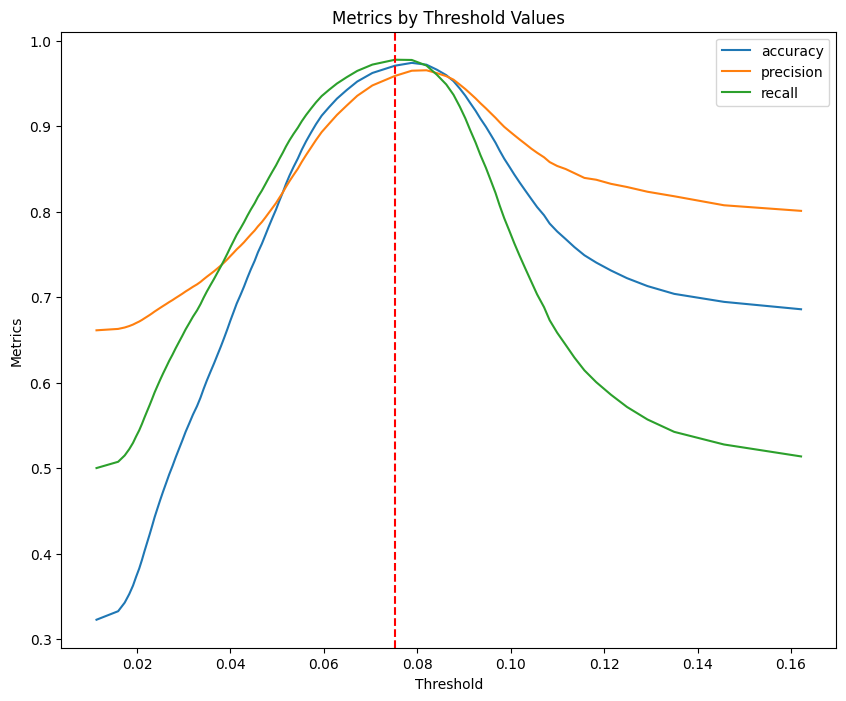

In [15]:
plt.figure(figsize=(10,8))
plt.plot(thresh_df['threshold'], thresh_df['accuracy'], label='accuracy')
plt.plot(thresh_df['threshold'], thresh_df['precision'], label='precision')
plt.plot(thresh_df['threshold'], thresh_df['recall'], label='recall')
plt.axvline(x=threshold, color='r', linestyle='dashed')
plt.xlabel('Threshold')
plt.ylabel('Metrics')
plt.title('Metrics by Threshold Values')
plt.legend()
plt.show()

/usr/local/lib/python3.10/dist-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
/usr/local/lib/python3.10/dist-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])


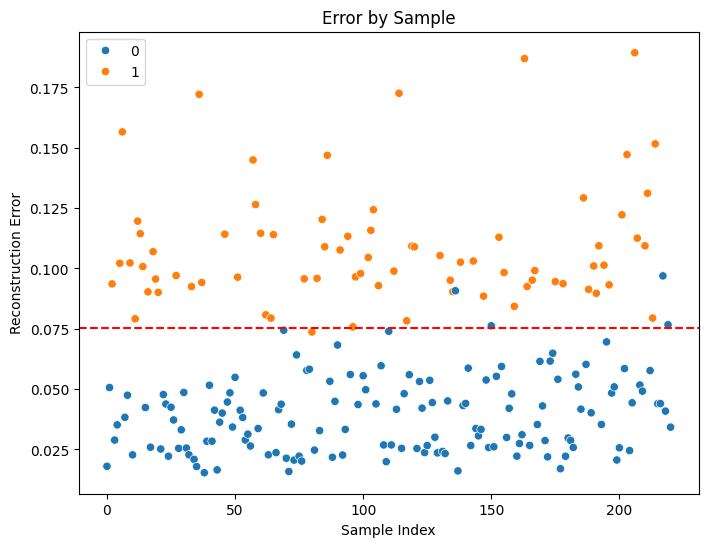

In [16]:
temp = recons_df.sample(frac=0.01, random_state=42).reset_index(drop=True)
plt.figure(figsize=(8,6))
sns.scatterplot(data=temp, x=temp.index, y='error', hue='y_true')
plt.axhline(y=threshold, color='r', linestyle='dashed')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Error by Sample')
plt.legend()
plt.show()